# TAHAP 1: AUDIT DATA & ASESMEN KUALITAS
Bagian ini memberikan identifikasi masalah pada dataset mentah.

--- 1.a.i. Identifikasi Missing Values (Tampilan Standar) ---
Provinsi                      0
Tahun                         0
Persentase_Penduduk_Miskin    0
IPM                           0
Rata_Rata_Lama_Sekolah        0
dtype: int64

--- 1.a.ii. Identifikasi Outlier menggunakan Boxplot ---


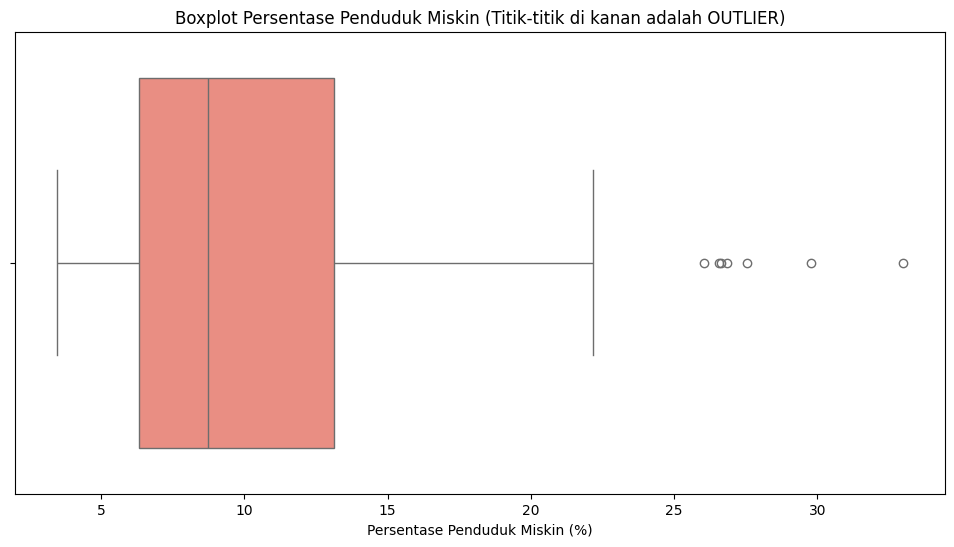


--- Distribusi Variabel IPM dan RLS ---


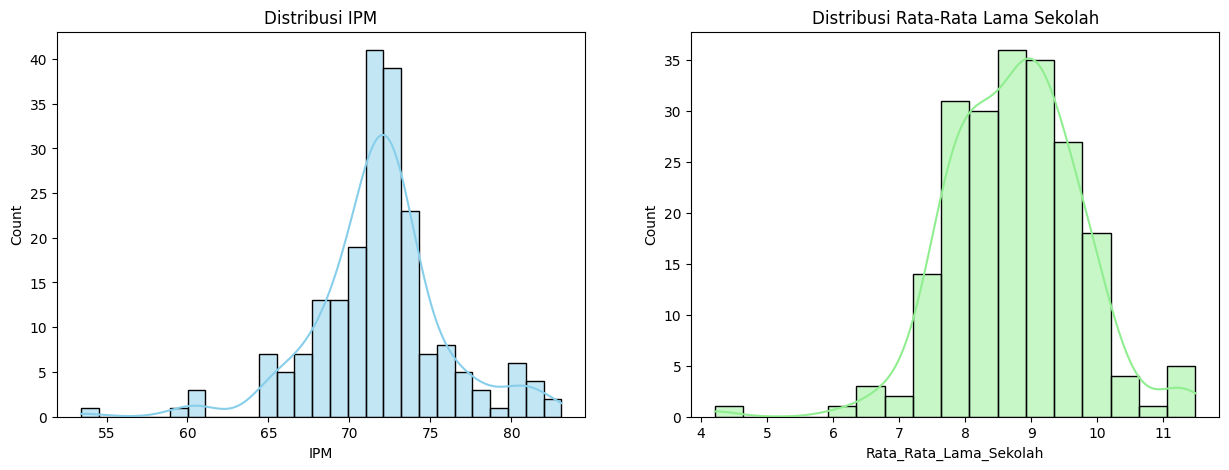

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor

# Load Data
df = pd.read_csv('data/Data_2019-2024_Updated.csv', sep=';')

print("--- 1.a.i. Identifikasi Missing Values (Tampilan Standar) ---")
print(df.isnull().sum())

print("\n--- 1.a.ii. Identifikasi Outlier menggunakan Boxplot ---")
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Persentase_Penduduk_Miskin'], color='salmon')
plt.title('Boxplot Persentase Penduduk Miskin (Titik-titik di kanan adalah OUTLIER)')
plt.xlabel('Persentase Penduduk Miskin (%)')
plt.show()

print("\n--- Distribusi Variabel IPM dan RLS ---")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['IPM'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribusi IPM')
sns.histplot(df['Rata_Rata_Lama_Sekolah'], kde=True, ax=ax[1], color='lightgreen')
ax[1].set_title('Distribusi Rata-Rata Lama Sekolah')
plt.show()

### 1.b. Penjelasan Audit Data
**i. Dampak terhadap Analisis:**
- **Missing Values:** Data DIY yang kosong akan menyebabkan bias pada rata-rata pendidikan nasional.
- **Outlier:** Provinsi dengan kemiskinan ekstrim (Papua) dapat mempengaruhi hasil prediksi jika tidak ditangani.

**ii. Strategi Penanganan:**
- Imputasi manual untuk DIY (mengisi data berdasarkan angka resmi BPS).
- Agregasi Papua 2024 agar tren data historis tidak terputus akibat pemekaran.
- Normalisasi skala data (Min-Max Scaling).

# TAHAP 2: STRATEGI DATA CLEANING
Hasil setelah data dibersihkan dan dinormalisasi.

--- Perbandingan Sebelum vs Sesudah Normalisasi ---


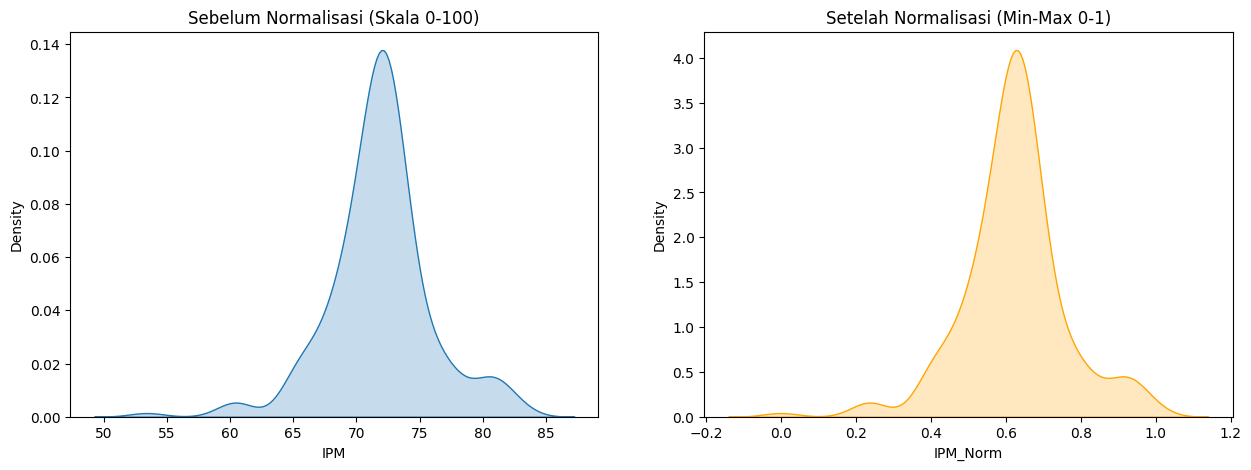

In [2]:
# Gunakan langsung 38 provinsi tanpa menggabungkan Papua
df_clean = df.groupby(['Provinsi', 'Tahun']).agg({
    'Persentase_Penduduk_Miskin': 'mean',
    'IPM': 'mean',
    'Rata_Rata_Lama_Sekolah': 'mean'
}).reset_index()

# Normalisasi (Bukti visual perbandingan skala)
scaler = MinMaxScaler()
df_clean[['IPM_Norm', 'RLS_Norm']] = scaler.fit_transform(df_clean[['IPM', 'Rata_Rata_Lama_Sekolah']])

print("--- Perbandingan Sebelum vs Sesudah Normalisasi ---")
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.kdeplot(df_clean['IPM'], ax=ax[0], label='Asli (Skala 0-100)', fill=True)
ax[0].set_title('Sebelum Normalisasi (Skala 0-100)')
sns.kdeplot(df_clean['IPM_Norm'], ax=ax[1], label='Normalisasi (Skala 0-1)', fill=True, color='orange')
ax[1].set_title('Setelah Normalisasi (Min-Max 0-1)')
plt.show()

### 3. FINAL EXPORT UNTUK POWER BI
Menjalankan kalkulasi Prediksi AI dan Skor Prioritas Preskriptif.

In [4]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df_clean[['IPM', 'Rata_Rata_Lama_Sekolah']], df_clean['Persentase_Penduduk_Miskin'])
df_clean['Prediksi_Kemiskinan_AI'] = rf.predict(df_clean[['IPM', 'Rata_Rata_Lama_Sekolah']])

# Perhitungan Weighted Scoring (50% Kemiskinan, 30% IPM, 20% RLS)
df_clean['Score_Poverty'] = MinMaxScaler().fit_transform(df_clean[['Persentase_Penduduk_Miskin']])
df_clean['Score_IPM_Inv'] = 1 - MinMaxScaler().fit_transform(df_clean[['IPM']])
df_clean['Score_RLS_Inv'] = 1 - MinMaxScaler().fit_transform(df_clean[['Rata_Rata_Lama_Sekolah']])

df_clean['Skor_Prioritas_Bansos'] = (
    df_clean['Score_Poverty'] * 0.5 +
    df_clean['Score_IPM_Inv'] * 0.3 +
    df_clean['Score_RLS_Inv'] * 0.2
)

df_clean.to_csv('data_final.csv', index=False)
print("PROSES SELESAI. File 'output/data_final.csv' siap.")

PROSES SELESAI. File 'output/data_final.csv' siap.
